# BPR Financial Distress Early Warning
## 01 — Data audit and target design

This notebook validates the repository's actual panel structure before modeling. It does **not** treat missing reports as zero and does **not** claim to observe default or regulatory distress. The proposed outcome is explicitly a next-year financial-deterioration proxy.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SEED = 42
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "Client-BPRSK" / "BPRSK"
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
from xcap_ews.visualization import TIKET, set_tiket_style
set_tiket_style()
from xcap_ews.visualization import TIKET, set_tiket_style
set_tiket_style()

bpr = pd.read_csv(DATA_DIR / "FinalBPRK.csv")
bprs_raw = pd.read_csv(DATA_DIR / "Main" / "Full1024BPRS.csv")
locations = pd.read_csv(DATA_DIR / "Main" / "BankLongLat.csv")

print(f"Repository root: {ROOT.resolve()}")
print(f"BPR: {bpr.shape}; BPRS pre-merge: {bprs_raw.shape}; locations: {locations.shape}")

Repository root: /Users/mraffyzeidan/Downloads/xcap
BPR: (27945, 33); BPRS pre-merge: (2910, 43); locations: (2055, 6)


## 1. Panel grain and availability

The exported BPR table has one skeleton row per roster bank and year. A row is considered observed below only when `Total_Aset` is non-null. This avoids interpreting the rectangular export as a genuinely balanced operating-bank panel.

,BPR,BPRS
rows,27945,2910
banks,1863,190
period_min,2010,2010
period_max,2024,2024
duplicate_bank_year,0,60
provinces,33,25
cities_regencies,297,109


,Tahun,skeleton_rows,observed_assets,unique_banks
0,2010,1863,1597,1863
1,2011,1863,1631,1863
2,2012,1863,1598,1863
3,2013,1863,1094,1863
4,2014,1863,1598,1863
5,2015,1863,1613,1863
6,2016,1863,1600,1863
7,2017,1863,1595,1863
8,2018,1863,1568,1863
9,2019,1863,1479,1863


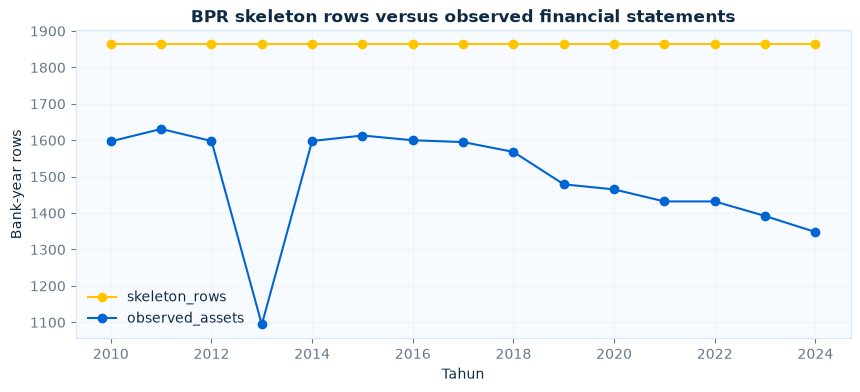

In [2]:
def panel_summary(df: pd.DataFrame, bank_col: str = "Kode_Bank") -> pd.Series:
    return pd.Series({
        "rows": len(df),
        "banks": df[bank_col].nunique(dropna=False),
        "period_min": int(df["Tahun"].min()),
        "period_max": int(df["Tahun"].max()),
        "duplicate_bank_year": int(df.duplicated([bank_col, "Tahun"]).sum()),
        "provinces": df["Provinsi"].nunique(),
        "cities_regencies": df["Kabupaten_Kota"].nunique(),
    })

display(pd.concat({"BPR": panel_summary(bpr), "BPRS": panel_summary(bprs_raw)}, axis=1))

coverage = (bpr.assign(observed=bpr["Total_Aset"].notna())
            .groupby("Tahun", as_index=False)
            .agg(skeleton_rows=("Kode_Bank", "size"),
                 observed_assets=("observed", "sum"),
                 unique_banks=("Kode_Bank", "nunique")))
display(coverage)

ax = coverage.plot(x="Tahun", y=["skeleton_rows", "observed_assets"], marker="o", figsize=(10, 4), color=[TIKET['yellow'], TIKET['blue']])
ax.set(title="BPR skeleton rows versus observed financial statements", ylabel="Bank-year rows")
ax.grid(alpha=0.25)
plt.show()

## 2. Missingness and suspicious ratio values

Missing and zero are reported separately because the legacy scraper sometimes converts missing or unparsable values to zero. Extreme values are audit flags, not observations to remove automatically.

In [3]:
financial_columns = [
    "Total_Aset", "Jumlah_Kredit", "Tabungan", "Deposito",
    "Total_Ekuitas", "Cadangan_Kerugian_Penurunan_Nilai",
    "NPL_Gross", "NPL_Neto", "ROA", "BOPO", "NIM",
    "LDR", "KPMM", "Cash_Ratio",
]

quality = []
for column in financial_columns:
    values = pd.to_numeric(bpr[column], errors="coerce")
    quality.append({
        "variable": column,
        "missing_pct": values.isna().mean(),
        "zero_pct": values.eq(0).mean(),
        "negative_pct": values.lt(0).mean(),
        "median": values.median(),
        "p99": values.quantile(0.99),
        "maximum": values.max(),
    })
quality = pd.DataFrame(quality).set_index("variable")
display(quality.style.format({"missing_pct": "{:.1%}", "zero_pct": "{:.1%}", "negative_pct": "{:.1%}"}))

,missing_pct,zero_pct,negative_pct,median,p99,maximum
variable,,,,,,
Total_Aset,19.7%,0.5%,0.0%,27607245.000000,178927226208.180145,11205464194745.000000
Jumlah_Kredit,19.7%,0.7%,0.0%,20140914.000000,120004806916.740097,9125526882593.000000
Tabungan,19.7%,17.4%,0.0%,3509448.500000,41331814257.650009,1597118401441.000000
Deposito,19.7%,17.8%,0.0%,8227212.000000,87874025232.950058,4254124176654.000000
Total_Ekuitas,19.7%,0.5%,0.5%,6836862.000000,28149844796.750008,1365307628997.000000
Cadangan_Kerugian_Penurunan_Nilai,19.7%,0.7%,0.0%,411398.500000,3962150213.230004,102178364933.000000
NPL_Gross,37.2%,21.3%,0.0%,2.570000,49.842900,717.000000
NPL_Neto,37.2%,0.7%,0.0%,5.200000,42.370000,1559.000000
ROA,41.6%,0.4%,5.2%,2.890000,17.097700,989.000000


## 3. Confirm the 2024 monetary-unit discontinuity

Within-bank year-over-year ratios should be near one for balance-sheet stocks. A common jump near 1,000 indicates a presentation-unit change, not economic growth.

In [4]:
def within_bank_growth_summary(
    df: pd.DataFrame, start_year: int, end_year: int, columns: list[str]
) -> pd.DataFrame:
    earlier = df.loc[df["Tahun"].eq(start_year)].set_index("Kode_Bank")
    later = df.loc[df["Tahun"].eq(end_year)].set_index("Kode_Bank")
    rows = []
    for column in columns:
        ratio = later[column].div(earlier[column]).replace([np.inf, -np.inf], np.nan)
        ratio = ratio.loc[ratio.gt(0)].dropna()
        rows.append({
            "transition": f"{start_year}→{end_year}",
            "variable": column,
            "n": len(ratio),
            "p25": ratio.quantile(0.25),
            "median": ratio.median(),
            "p75": ratio.quantile(0.75),
        })
    return pd.DataFrame(rows)

money = ["Total_Aset", "Jumlah_Kredit", "Tabungan", "Deposito", "Total_Ekuitas"]
unit_check = pd.concat([
    within_bank_growth_summary(bpr, 2022, 2023, money),
    within_bank_growth_summary(bpr, 2023, 2024, money),
], ignore_index=True)
display(unit_check)

assert unit_check.loc[unit_check["transition"].eq("2023→2024"), "median"].min() > 900, (
    "Expected 2024 unit break was not found; re-check the source files."
)

,transition,variable,n,p25,median,p75
0,2022→2023,Total_Aset,1391,0.989,1.064,1.161
1,2022→2023,Jumlah_Kredit,1380,0.981,1.081,1.203
2,2022→2023,Tabungan,1385,0.945,1.053,1.192
3,2022→2023,Deposito,1370,0.975,1.079,1.222
4,2022→2023,Total_Ekuitas,1373,0.996,1.047,1.111
5,2023→2024,Total_Aset,1348,979.852,"1,048.535","1,132.807"
6,2023→2024,Jumlah_Kredit,1339,956.576,"1,055.699","1,160.534"
7,2023→2024,Tabungan,1343,948.700,"1,056.396","1,176.105"
8,2023→2024,Deposito,1333,954.473,"1,056.765","1,180.984"
9,2023→2024,Total_Ekuitas,1337,994.937,"1,043.537","1,119.805"


## 4. Candidate forward target

For bank $i$ at observation year $t$, the candidate label is realized at $t+1$. A component is adverse when:

- NPL net increases by at least 2 percentage points;
- ROA decreases by at least 1 percentage point;
- BOPO increases by at least 5 percentage points; or
- KPMM decreases by at least 5 percentage points.

The binary proxy equals one when at least two components deteriorate. All four ratios must be present in consecutive years. These thresholds are proposed before modeling and require development-period sensitivity analysis.

,target_year,eligible,deterioration_events,deterioration_rate
0,2014.000000,887,243,27.4%
1,2015.000000,1211,340,28.1%
2,2016.000000,1204,253,21.0%
3,2017.000000,1188,267,22.5%
4,2018.000000,1162,289,24.9%
5,2019.000000,1222,320,26.2%
6,2020.000000,1483,585,39.4%
7,2021.000000,1458,375,25.7%
8,2022.000000,1428,354,24.8%
9,2023.000000,1391,445,32.0%


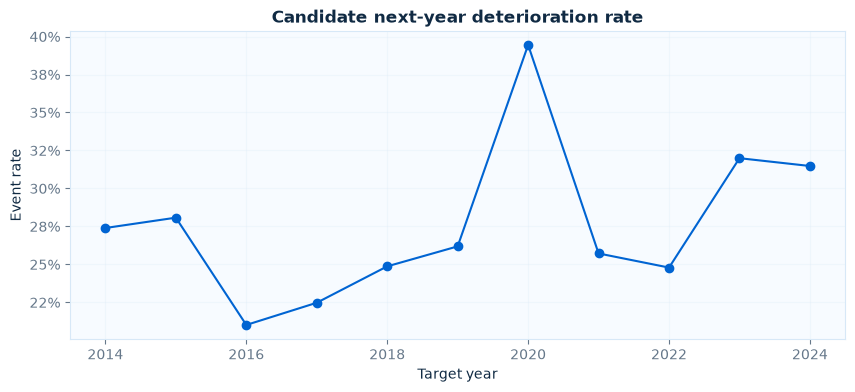

In [5]:
TARGET_THRESHOLDS = {
    "NPL_Neto": 2.0,   # adverse direction: increase
    "ROA": -1.0,       # adverse direction: decrease
    "BOPO": 5.0,       # adverse direction: increase
    "KPMM": -5.0,      # adverse direction: decrease
}

def build_candidate_target(df: pd.DataFrame) -> pd.DataFrame:
    result = df.sort_values(["Kode_Bank", "Tahun"]).copy()
    grouped = result.groupby("Kode_Bank", sort=False)
    result["target_year"] = grouped["Tahun"].shift(-1)
    consecutive = result["target_year"].eq(result["Tahun"] + 1)

    component_columns = []
    for ratio, threshold in TARGET_THRESHOLDS.items():
        future = grouped[ratio].shift(-1)
        change = future - result[ratio]
        result[f"target_change__{ratio}"] = change
        component = f"target_component__{ratio}"
        result[component] = change.ge(threshold) if threshold > 0 else change.le(threshold)
        component_columns.append(component)

    endpoints_complete = result[list(TARGET_THRESHOLDS)].notna().all(axis=1)
    future_complete = pd.concat(
        [grouped[ratio].shift(-1).notna().rename(ratio) for ratio in TARGET_THRESHOLDS], axis=1
    ).all(axis=1)
    eligible = consecutive & endpoints_complete & future_complete
    result["target_adverse_component_count"] = result[component_columns].sum(axis=1).where(eligible)
    result["next_period_deterioration"] = (
        result["target_adverse_component_count"].ge(2).astype("Int64").where(eligible)
    )
    return result

target_panel = build_candidate_target(bpr)
target_audit = (target_panel.dropna(subset=["next_period_deterioration"])
                .groupby("target_year")
                .agg(eligible=("Kode_Bank", "size"),
                     deterioration_events=("next_period_deterioration", "sum"),
                     deterioration_rate=("next_period_deterioration", "mean"))
                .reset_index())
display(target_audit.style.format({"deterioration_rate": "{:.1%}"}))

ax = target_audit.plot(x="target_year", y="deterioration_rate", marker="o", figsize=(10, 4), legend=False, color=TIKET['blue'])
ax.set(title="Candidate next-year deterioration rate", ylabel="Event rate", xlabel="Target year")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.grid(alpha=0.25)
plt.show()

## 5. Geographic quality gate

Coordinates exist, but identical coordinates shared by many banks can manufacture artificial nearest-neighbor structure. Administrative leave-one-bank-out peers are the safer initial benchmark.

In [6]:
coordinate_groups = (locations.groupby(["Latitude", "Longitude"], dropna=False)
                     .size().rename("banks_at_coordinate").sort_values(ascending=False))
location_audit = pd.Series({
    "rows": len(locations),
    "unique_names": locations["Nama Bank"].nunique(),
    "missing_latitude": locations["Latitude"].isna().sum(),
    "missing_longitude": locations["Longitude"].isna().sum(),
    "shared_coordinate_groups": coordinate_groups.ge(2).sum(),
    "rows_in_shared_coordinates": coordinate_groups.loc[coordinate_groups.ge(2)].sum(),
    "largest_coordinate_group": coordinate_groups.max(),
})
display(location_audit.to_frame("value"))
display(coordinate_groups.head(15).to_frame())

,value
rows,2055
unique_names,2051
missing_latitude,0
missing_longitude,0
shared_coordinate_groups,55
rows_in_shared_coordinates,241
largest_coordinate_group,53


banks_at_coordinate
Latitude Longitude                     
-6.239   106.791                     53
         106.709                     51
-6.238   106.544                     10
-6.237   106.214                     10
-6.176   106.640                      6
-6.331   107.039                      4
-6.250   107.025                      4
-0.592   100.733                      4
-7.571   110.820                      3
-6.267   107.077                      3
-1.349   100.573                      3
-2.164   115.380                      3
-6.268   107.127                      3
-6.364   107.170                      2
2.603    98.702                       2

## 6. Out-of-time validation design

Splits use the year in which deterioration is realized. The final 2024 target year remains locked until all choices are finalized.

In [7]:
validation_years = list(range(2019, 2025))
folds = pd.DataFrame({
    "fold": [1, 2, 3, 4, 5, "Final"],
    "train_target_years": [f"2016–{year - 1}" for year in validation_years],
    "validation_target_year": validation_years,
    "purpose": [
        "Report-schema boundary stress test",
        "COVID-era shift",
        "Out-of-time test",
        "Out-of-time test",
        "Recent out-of-time test",
        "Locked final holdout",
    ],
})
display(folds)

,fold,train_target_years,validation_target_year,purpose
0,1,2016–2018,2019,Report-schema boundary stress test
1,2,2016–2019,2020,COVID-era shift
2,3,2016–2020,2021,Out-of-time test
3,4,2016–2021,2022,Out-of-time test
4,5,2016–2022,2023,Recent out-of-time test
5,Final,2016–2023,2024,Locked final holdout


## 7. BPRS separation decision

BPRS remains a separate future modeling track. Its pre-2019 schema lacks comparable BOPO/NPF-gross measures, four bank codes have conflicting locations, and the final name-only geographic merge multiplies rows.

In [8]:
bprs_duplicate_keys = (bprs_raw.loc[bprs_raw.duplicated(["Kode_Bank", "Tahun"], keep=False),
                                    ["Kode_Bank", "Nama_BPR", "Provinsi", "Kabupaten_Kota"]]
                       .drop_duplicates().sort_values(["Kode_Bank", "Kabupaten_Kota"]))
display(bprs_duplicate_keys)

bprs_ratio_coverage = (bprs_raw.groupby("Tahun")[["NPF_Neto", "NPF_Gross", "ROA", "BOPO", "KPMM", "FDR"]]
                       .count())
display(bprs_ratio_coverage)

,Kode_Bank,Nama_BPR,Provinsi,Kabupaten_Kota
45,620001,PT BPRS Berkah Amal Salman,Provinsi Jawa Barat,Kota Bandung
180,620001,PT BPRS Berkah Amal Salman,Provinsi Jawa Barat,Kota Bogor
107,620011,PT Bank Perekonomian Rakyat Syariah Baiturridh...,Provinsi Jawa Barat,Kota Bandung
176,620011,PT Bank Perekonomian Rakyat Syariah Baiturridh...,Provinsi Jawa Barat,Kota Bogor
111,620161,PT Bank Perekonomian Rakyat Syariah Mitra Harm...,Provinsi Jawa Barat,Kota Bandung
179,620161,PT Bank Perekonomian Rakyat Syariah Mitra Harm...,Provinsi Jawa Barat,Kota Bogor
50,620172,PT. BPRS Gotong Royong,Provinsi Jawa Barat,Kab. Subang
136,620172,PT. BPRS Gotong Royong,Provinsi Jawa Barat,Kota Sukabumi


,NPF_Neto,NPF_Gross,ROA,BOPO,KPMM,FDR
Tahun,,,,,,
2010,0,0,0,0,0,0
2011,128,0,128,0,128,128
2012,146,0,146,0,146,146
2013,148,0,148,0,148,148
2014,139,0,139,0,139,139
2015,149,0,149,0,149,149
2016,153,0,153,0,153,153
2017,153,0,153,0,153,153
2018,150,0,150,0,150,150


## Decision

Proceed next with a conventional-BPR cleaning layer, canonical identity table, report-status lineage, and documented monetary-unit normalization. Only then build leakage-safe financial/trend features and statistical baselines. Spatial diagnostics and features follow coordinate validation and must demonstrate incremental out-of-time value.

See `docs/data_audit_and_modeling_plan.md` for the full rationale, feature plan, regional enrichment contract, evaluation design, and leakage register.